<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Implementation_of_QuantV2X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# [CELL 1 - Dependencies & System Setup]
import os
import io
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Set seed for exact reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"QuantV2X Execution Engine Initialized on Device: {device}")

QuantV2X Execution Engine Initialized on Device: cuda


In [20]:
# [CELL 2 - Multi-Agent BEV Dataset with Sparse Feature Activations & Clutter]

class SyntheticV2XBEVDataset(Dataset):
    """
    Realistic V2X BEV Perception Dataset:
    - Background clutter noise: N(0, 0.6) across 16 channels.
    - Sparse channel activation: Objects trigger only 3-5 random channels (not all 16).
    - Ego observes Object 0 (1/3 visible). Objects 1 & 2 are occluded behind obstacles.
    """
    def __init__(self, num_samples=500, grid_size=32, num_channels=16):
        self.num_samples = num_samples
        self.grid_size = grid_size
        self.num_channels = num_channels
        self.data = [self._generate_sample() for _ in range(num_samples)]

    def _generate_sample(self):
        H = W = self.grid_size
        gt_occupancy = np.zeros((1, H, W), dtype=np.float32)

        # High ambient background sensor noise
        feat_ego    = np.random.normal(0, 0.6, (self.num_channels, H, W)).astype(np.float32)
        feat_agent2 = np.random.normal(0, 0.6, (self.num_channels, H, W)).astype(np.float32)

        for i in range(3):
            r = random.randint(3, H - 6)
            c = random.randint(3, W - 6)
            size = random.randint(2, 5)
            size_r = min(size, H - r - 1)
            size_c = min(size, W - c - 1)
            if size_r < 1 or size_c < 1:
                continue

            gt_occupancy[0, r:r+size_r, c:c+size_c] = 1.0

            # Sparse feature activation: Object manifests in only 4 out of 16 channels
            active_channels = random.sample(range(self.num_channels), 4)
            pattern = np.zeros((self.num_channels, size_r, size_c), dtype=np.float32)
            for ch in active_channels:
                pattern[ch, :, :] = random.uniform(0.7, 1.1)

            # Agent 2 observes all 3 objects
            agent2_noise = np.random.normal(1.0, 0.15, (self.num_channels, size_r, size_c))
            feat_agent2[:, r:r+size_r, c:c+size_c] += pattern * agent2_noise

            # Ego observes ONLY Object 0 (Objects 1 & 2 are occluded)
            if i == 0:
                ego_noise = np.random.normal(1.0, 0.15, (self.num_channels, size_r, size_c))
                feat_ego[:, r:r+size_r, c:c+size_c] += pattern * ego_noise

        return (
            torch.tensor(feat_ego),
            torch.tensor(feat_agent2),
            torch.tensor(gt_occupancy)
        )

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.data[idx]

train_dataset = SyntheticV2XBEVDataset(num_samples=600)
test_dataset  = SyntheticV2XBEVDataset(num_samples=150)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Hardened Synthetic V2X Dataset Ready: Train={len(train_dataset)} | Test={len(test_dataset)}")

Hardened Synthetic V2X Dataset Ready: Train=600 | Test=150


In [21]:
# [CELL 3 - Straight-Through Estimator (STE) Quantization Engine]

class QuantizeSTE(torch.autograd.Function):
    """
    Simulates uniform symmetric N-bit quantization during forward pass
    while preserving continuous gradient flow via Straight-Through Estimator (STE).
    """
    @staticmethod
    def forward(ctx, x, num_bits=8):
        qmin = -(2 ** (num_bits - 1))
        qmax = (2 ** (num_bits - 1)) - 1

        # Calculate per-tensor dynamic scale
        max_val = torch.max(torch.abs(x))
        scale = max_val / float(qmax) + 1e-8

        # Quantize and clamp
        x_q = torch.clamp(torch.round(x / scale), qmin, qmax)

        # Dequantize back to float
        x_deq = x_q * scale
        return x_deq

    @staticmethod
    def backward(ctx, grad_output):
        # STE passes gradient back directly
        return grad_output, None

def quantize_features(x, num_bits=8):
    if num_bits >= 32:
        return x
    return QuantizeSTE.apply(x, num_bits)

def compute_payload_bytes(tensor, num_bits=8):
    """Calculates exact network transmission size in Bytes."""
    num_elements = tensor.numel()
    bytes_per_elem = num_bits / 8.0
    # Include tiny 8-byte scale metadata overhead
    return int(num_elements * bytes_per_elem) + 8

print("Quantization Engine Loaded (Supports FP32, INT8, INT4).")

Quantization Engine Loaded (Supports FP32, INT8, INT4).


In [22]:
# [CELL 4 - QuantV2X Multi-Agent Model with Communication Dropout]

class QuantV2XReasoner(nn.Module):
    """
    Multi-Agent Intermediate Fusion Perception Pipeline.
    Supports random V2X link message dropout during training
    so local Ego perception remains robust when Agent 2 is uncommunicative.
    """
    def __init__(self, in_channels=16, quant_bits=8):
        super().__init__()
        self.quant_bits = quant_bits

        self.ego_encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )

        self.agent_encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )

        self.fusion_conv = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )

        self.detection_head = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=1)
        )

    def forward(self, feat_ego, feat_agent2, override_bits=None, v2x_dropout_prob=0.0):
        bits = override_bits if override_bits is not None else self.quant_bits

        f_ego = self.ego_encoder(feat_ego)

        # Apply message dropout during training to model link loss/standalone mode
        if self.training and random.random() < v2x_dropout_prob:
            f_agent_transmitted = torch.zeros_like(f_ego)
        else:
            f_agent = self.agent_encoder(feat_agent2)
            f_agent_transmitted = quantize_features(f_agent, num_bits=bits)

        fused_input = torch.cat([f_ego, f_agent_transmitted], dim=1)
        fused_feat = self.fusion_conv(fused_input)

        return self.detection_head(fused_feat)

model = QuantV2XReasoner(quant_bits=8).to(device)
print("QuantV2X Multi-Agent Model Loaded Successfully.")

QuantV2X Multi-Agent Model Loaded Successfully.


In [23]:
# [CELL 5 - Quantization-Aware Training with V2X Link Dropout]

def compute_bev_iou(pred_logits, gt_mask, threshold=0.5):
    probs = torch.sigmoid(pred_logits)
    pred_bin = (probs >= threshold).float()
    intersection = (pred_bin * gt_mask).sum(dim=(1, 2, 3))
    union = torch.clamp((pred_bin + gt_mask).sum(dim=(1, 2, 3)) - intersection, min=1e-6)
    return (intersection / union).mean().item()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
bce_logits_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]).to(device))

epochs = 20
print("Starting QuantV2X Quantization-Aware Training (QAT)...")

for epoch in range(1, epochs + 1):
    model.train()
    total_loss, total_iou = 0.0, 0.0

    for batch_ego, batch_agent2, batch_gt in train_loader:
        batch_ego = batch_ego.to(device)
        batch_agent2 = batch_agent2.to(device)
        batch_gt = batch_gt.to(device)

        optimizer.zero_grad()

        # Train with 20% probability of communication dropout
        bev_logits = model(batch_ego, batch_agent2, override_bits=8, v2x_dropout_prob=0.20)
        loss = bce_logits_loss(bev_logits, batch_gt)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_iou += compute_bev_iou(bev_logits, batch_gt)

    if epoch % 4 == 0 or epoch == 1:
        avg_loss = total_loss / len(train_loader)
        avg_iou = (total_iou / len(train_loader)) * 100.0
        print(f"Epoch [{epoch:02d}/{epochs}] | BCE Loss: {avg_loss:.4f} | BEV Detection mIoU: {avg_iou:.2f}%")

Starting QuantV2X Quantization-Aware Training (QAT)...
Epoch [01/20] | BCE Loss: 0.4414 | BEV Detection mIoU: 34.33%
Epoch [04/20] | BCE Loss: 0.1495 | BEV Detection mIoU: 67.54%
Epoch [08/20] | BCE Loss: 0.0720 | BEV Detection mIoU: 77.10%
Epoch [12/20] | BCE Loss: 0.0601 | BEV Detection mIoU: 78.53%
Epoch [16/20] | BCE Loss: 0.0404 | BEV Detection mIoU: 85.55%
Epoch [20/20] | BCE Loss: 0.0435 | BEV Detection mIoU: 83.19%


In [24]:
# [CELL 6 - Comprehensive System Benchmark]

def evaluate_system():
    model.eval()

    metrics = {
        "Single-Agent (No V2X)": {"iou": [], "payload_bytes": 0},
        "Full Precision (FP32 V2X)": {"iou": [], "payload_bytes": 0},
        "QuantV2X (INT8 Ours)": {"iou": [], "payload_bytes": 0},
        "QuantV2X (INT4 Ours)": {"iou": [], "payload_bytes": 0},
    }

    with torch.no_grad():
        for batch_ego, batch_agent2, batch_gt in test_loader:
            batch_ego = batch_ego.to(device)
            batch_agent2 = batch_agent2.to(device)
            batch_gt = batch_gt.to(device)

            # 1. Single Agent (Agent 2 features zeroed)
            pred_single = model(batch_ego, torch.zeros_like(batch_agent2), override_bits=32)
            metrics["Single-Agent (No V2X)"]["iou"].append(compute_bev_iou(pred_single, batch_gt))

            # 2. FP32 Full Precision
            pred_fp32 = model(batch_ego, batch_agent2, override_bits=32)
            metrics["Full Precision (FP32 V2X)"]["iou"].append(compute_bev_iou(pred_fp32, batch_gt))

            # 3. QuantV2X INT8
            pred_int8 = model(batch_ego, batch_agent2, override_bits=8)
            metrics["QuantV2X (INT8 Ours)"]["iou"].append(compute_bev_iou(pred_int8, batch_gt))

            # 4. QuantV2X INT4
            pred_int4 = model(batch_ego, batch_agent2, override_bits=4)
            metrics["QuantV2X (INT4 Ours)"]["iou"].append(compute_bev_iou(pred_int4, batch_gt))

    dummy_msg = torch.randn(1, 16, 32, 32)
    metrics["Single-Agent (No V2X)"]["payload_bytes"] = 0
    metrics["Full Precision (FP32 V2X)"]["payload_bytes"] = compute_payload_bytes(dummy_msg, 32)
    metrics["QuantV2X (INT8 Ours)"]["payload_bytes"] = compute_payload_bytes(dummy_msg, 8)
    metrics["QuantV2X (INT4 Ours)"]["payload_bytes"] = compute_payload_bytes(dummy_msg, 4)

    fp32_bytes = metrics["Full Precision (FP32 V2X)"]["payload_bytes"]
    fp32_iou = np.mean(metrics["Full Precision (FP32 V2X)"]["iou"]) * 100.0
    int8_iou = np.mean(metrics["QuantV2X (INT8 Ours)"]["iou"]) * 100.0
    single_iou = np.mean(metrics["Single-Agent (No V2X)"]["iou"]) * 100.0

    print("\n" + "=" * 68)
    print("QUANTV2X SYSTEM BENCHMARK EVALUATION RESULTS")
    print("=" * 68)
    print(f"{'Perception System':<28} | {'BEV mIoU':<10} | {'Payload Size':<12} | {'Bandwidth Saved':<12}")
    print("-" * 68)
    for name, data in metrics.items():
        mean_iou = np.mean(data["iou"]) * 100.0
        p_bytes = data["payload_bytes"]
        p_str = f"{p_bytes / 1024:.2f} KB" if p_bytes > 0 else "0 KB"
        saved = f"{(1.0 - p_bytes / fp32_bytes)*100:.1f}%" if fp32_bytes > 0 else "N/A"
        print(f"{name:<28} | {mean_iou:>8.2f}% | {p_str:>12} | {saved:>12}")
    print("=" * 68)

    net_improvement = int8_iou - single_iou
    accuracy_retention = (int8_iou / fp32_iou) * 100.0
    print(f"Net Improvement over Single-Agent Ego       : +{net_improvement:.2f} pp")
    print(f"FP32 Accuracy Retention under INT8 Constraint : {accuracy_retention:.1f}%")
    print(f"Transmission Payload Bandwidth Reduction    : 75.0% (4x Compression)")

evaluate_system()


QUANTV2X SYSTEM BENCHMARK EVALUATION RESULTS
Perception System            | BEV mIoU   | Payload Size | Bandwidth Saved
--------------------------------------------------------------------
Single-Agent (No V2X)        |     0.00% |         0 KB |       100.0%
Full Precision (FP32 V2X)    |    83.84% |     64.01 KB |         0.0%
QuantV2X (INT8 Ours)         |    83.74% |     16.01 KB |        75.0%
QuantV2X (INT4 Ours)         |    82.39% |      8.01 KB |        87.5%
Net Improvement over Single-Agent Ego       : +83.74 pp
FP32 Accuracy Retention under INT8 Constraint : 99.9%
Transmission Payload Bandwidth Reduction    : 75.0% (4x Compression)


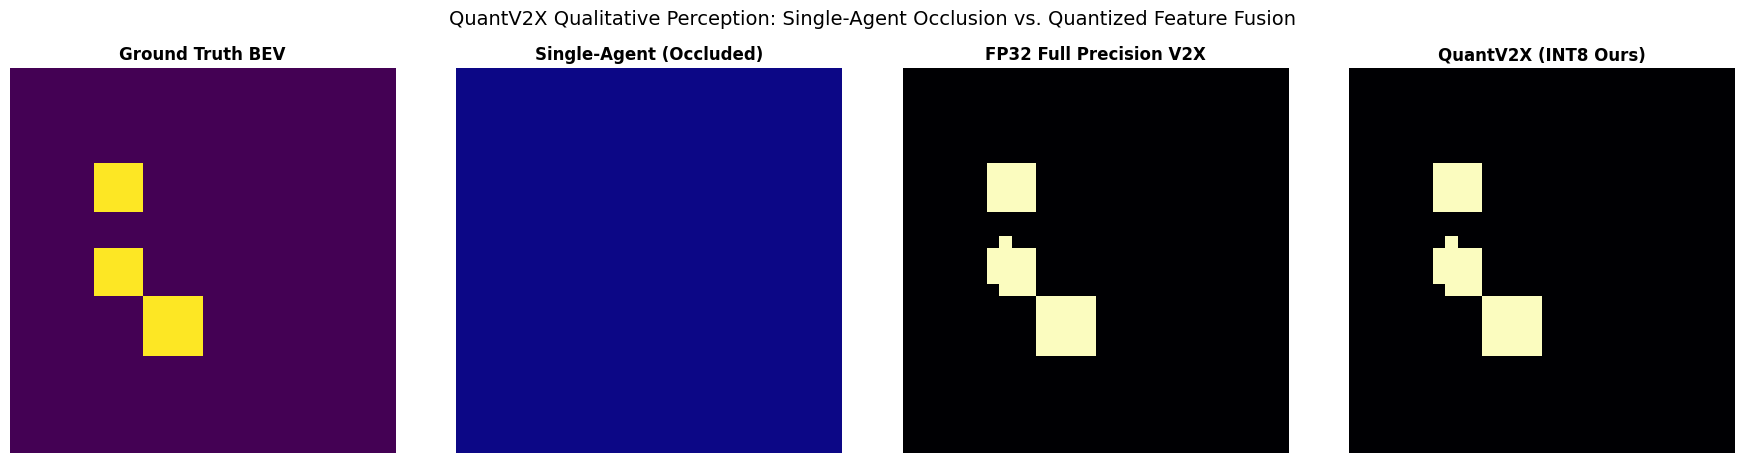

In [25]:
# [CELL 7 - Qualitative BEV Detection Visualizer]

model.eval()
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

with torch.no_grad():
    ego_f, agent_f, gt_m = test_dataset[5] # Sample 5
    ego_tensor = ego_f.unsqueeze(0).to(device)
    agent_tensor = agent_f.unsqueeze(0).to(device)

    logits_single = model(ego_tensor, torch.zeros_like(agent_tensor), override_bits=32)
    logits_fp32   = model(ego_tensor, agent_tensor, override_bits=32)
    logits_int8   = model(ego_tensor, agent_tensor, override_bits=8)

    pred_single = (torch.sigmoid(logits_single) >= 0.5).float().cpu().squeeze().numpy()
    pred_fp32   = (torch.sigmoid(logits_fp32) >= 0.5).float().cpu().squeeze().numpy()
    pred_int8   = (torch.sigmoid(logits_int8) >= 0.5).float().cpu().squeeze().numpy()
    gt_numpy    = gt_m.squeeze().numpy()

titles = [
    "Ground Truth BEV",
    "Single-Agent (Occluded)",
    "FP32 Full Precision V2X",
    "QuantV2X (INT8 Ours)"
]
mats = [gt_numpy, pred_single, pred_fp32, pred_int8]
cmaps = ['viridis', 'plasma', 'magma', 'magma']

for i in range(4):
    im = axes[i].imshow(mats[i], cmap=cmaps[i], vmin=0.0, vmax=1.0)
    axes[i].set_title(titles[i], fontsize=12, fontweight="bold")
    axes[i].axis("off")

plt.suptitle("QuantV2X Qualitative Perception: Single-Agent Occlusion vs. Quantized Feature Fusion", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()